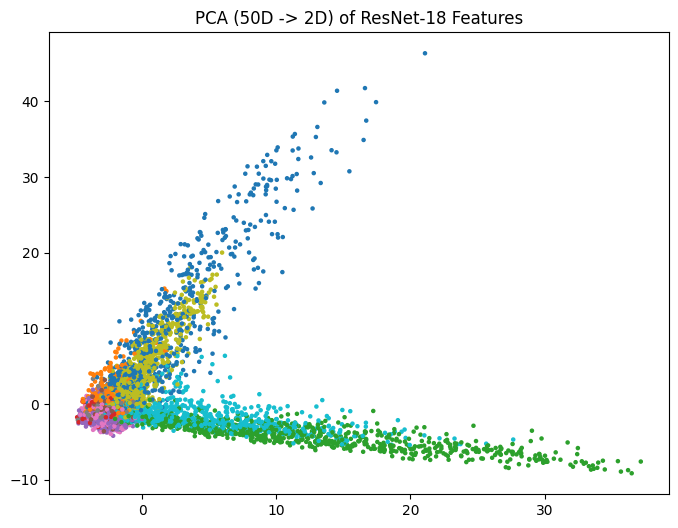

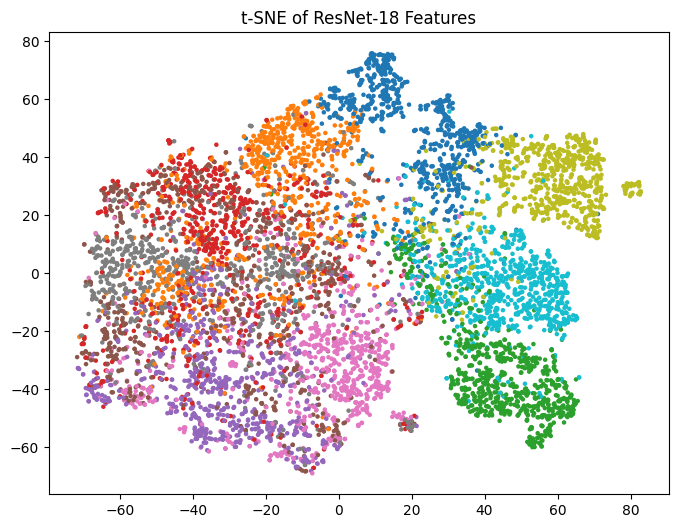

In [4]:
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import STL10
from torchvision import transforms, models
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# --------------------------
# Load STL-10 test set
# --------------------------
data_root = "/content/data"  # change if needed
batch_size = 256

test_transform = transforms.Compose([
    transforms.Resize(96),
    transforms.CenterCrop(96),
    transforms.ToTensor(),
])

test_dataset = STL10(root=data_root, split="test", download=True, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# --------------------------
# Load pretrained encoder
# --------------------------
encoder = models.resnet18(weights=None)
encoder.fc = torch.nn.Identity()
checkpoint_path = "/content/drive/MyDrive/ssl_checkpoints/byol_epoch_200.pth"  # change path

# Load checkpoint
state = torch.load(checkpoint_path, map_location=device)
encoder.load_state_dict(state)  # if you saved only encoder weights
encoder = encoder.to(device)
encoder.eval()

# --------------------------
# Extract features
# --------------------------
features_list = []
labels_list = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        feats = encoder(x)
        features_list.append(feats.cpu())
        labels_list.append(y)

features = torch.cat(features_list, dim=0).numpy()
labels = torch.cat(labels_list, dim=0).numpy()

# --------------------------
# PCA Visualization
# --------------------------
pca = PCA(n_components=50, random_state=42)
features_pca = pca.fit_transform(features)

plt.figure(figsize=(8, 6))
plt.scatter(features_pca[:, 0], features_pca[:, 1], c=labels, cmap='tab10', s=5)
plt.title("PCA (50D -> 2D) of ResNet-18 Features")
plt.show()

# --------------------------
# t-SNE Visualization
# --------------------------
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', random_state=42)
features_tsne = tsne.fit_transform(features_pca)  # PCA first for speed

plt.figure(figsize=(8, 6))
plt.scatter(features_tsne[:, 0], features_tsne[:, 1], c=labels, cmap='tab10', s=5)
plt.title("t-SNE of ResNet-18 Features")
plt.show()
